# Análisis de movilidad urbana y productividad económica en LATAM

## 📌 Introducción
Este proyecto analiza la relación entre la congestión urbana y la productividad económica en ciudades de América Latina.

## 🎯 Objetivo
Identificar patrones entre movilidad urbana y desempeño económico para apoyar la toma de decisiones.

## 🛠️ Datos utilizados
- TomTom Traffic Index
- OECD Cities

## 🧹 Limpieza y preparación de datos
Se realiza la limpieza, validación y unión de los datasets.

## 📊 Análisis exploratorio de datos
Se analizan las relaciones entre variables como congestión y PIB per cápita.

## 💡 Conclusiones

- Existe relación entre congestión y productividad  
- Algunas ciudades presentan bajo rendimiento económico y alta congestión  
- La mejora en movilidad puede impactar positivamente la economía  

In [1]:
# importar librerías
import pandas as pd
import numpy as nm
import seaborn as sb
import matplotlib.pyplot as mp

In [2]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [3]:
# mostrar las primeras 5 filas de traffic
print(traffic.head(10))

  Country       City            UpdateTimeUTC  JamsDelay  TrafficIndexLive  \
0     ARE  abu-dhabi  2025-01-13 04:01:30.001      650.7              36.0   
1     ARE  abu-dhabi  2025-01-13 03:46:00.000      540.4              30.0   
2     ARE  abu-dhabi  2025-01-13 02:46:30.000       71.8               7.0   
3     ARE  abu-dhabi  2025-01-13 01:46:30.001        8.2               2.0   
4     ARE  abu-dhabi  2025-01-13 00:01:30.000        1.1               1.0   
5     ARE  abu-dhabi  2025-01-12 23:01:30.000        5.6               2.0   
6     ARE  abu-dhabi  2025-01-12 22:31:30.000        5.0               2.0   
7     ARE  abu-dhabi  2025-01-12 21:01:30.001       10.2               3.0   
8     ARE  abu-dhabi  2025-01-12 20:01:30.000       40.9              13.0   
9     ARE  abu-dhabi  2025-01-12 19:16:30.000      197.9              17.0   

   JamsLengthInKms  JamsCount  TrafficIndexWeekAgo     UpdateTimeUTCWeekAgo  \
0            109.1      162.0                 30.0  2025-01-06

In [4]:
# mostrar las primeras 5 filas de eco
print(eco.head(10))

   Year            City    Country City GDP/capita Unemployment %  \
0  2023    buenos-aires  Argentina       15.782,00           6.2%   
1  2023       sao-paulo     Brazil       14.475,00           9.1%   
2  2023  rio-de-janeiro     Brazil       13.142,00           9.8%   
3  2023        brasilia     Brazil       15.999,00           8.3%   
4  2023        salvador     Brazil        8.761,00          13.1%   
5  2023       fortaleza     Brazil          838,00          12.5%   
6  2023  belo-horizonte     Brazil       10.951,00          10.1%   
7  2023        curitiba     Brazil       12.189,00           8.8%   
8  2023          recife     Brazil        9.047,00          11.8%   
9  2023    porto-alegre     Brazil       11.618,00           9.2%   

  PM2.5 (μg/m³) Population (M)  
0          15,2          15,30  
1         29,50          22,50  
2         19,10          13,60  
3         13,50           4,70  
4         16,00           3,90  
5         15,40           4,20  
6        

**Tip:** Si no usas `print()` la tabla se vera mejor.

In [5]:
# Examinar la estructura de traffic
traffic.info()  
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo ...
- ...

In [6]:
# Examinar la estructura de eco
eco.info()  
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, ...
- ... 

In [7]:
# Estandarizar los nombres de las columnas de traffi
# Para traffic - método directo y seguro
traffic.columns = [
    'country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live',
    'jams_length_in_kms', 'jams_count', 'traffic_index_week_ago', 
    'update_time_utc_week_ago', 'travel_time_live_per_10kms_mins',
    'travel_time_historic_per_10kms_mins', 'mins_delay'
]
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [8]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí
eco.columns = eco.columns.str.lower().str.replace(' ', '_').str.replace('/', '_').str.replace('(', '').str.replace(')', '').str.replace('%', 'pct').str.replace('μg_m³', 'ugm3').str.replace('.', '')
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25_ugm3', 'population_m'],
      dtype='object')

<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [9]:
# Convertir columnas de fecha en traffic (a prueba de errores)
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')

# Verificar cambios
traffic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

In [11]:

# 🔧 Limpieza de datos numéricos en eco

# GDP per capita
eco['city_gdp_capita'] = (
    eco['city_gdp_capita']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Unemployment %
eco['unemployment_pct'] = (
    eco['unemployment_pct']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Population (millones)
eco['population_m'] = (
    eco['population_m']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Crear población total
eco['population'] = eco['population_m'] * 1_000_000

# Verificar cambios
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25_ugm3         30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25_ugm3,population_m,population
0,2023,buenos-aires,Argentina,157820.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,144750.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,131420.0,9.8,"19,10",13.6,13600000.0


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Bien hecho! Has comprendido la estructura y tipo de datos, has corregido la nomenclatura de las columnas en el formato snake_case y los formatos de números y fechas. Buen trabajo.

In [12]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [13]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25_ugm3,population_m,population
15,2024,buenos-aires,Argentina,181170.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,147030.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,133490.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,162510.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,88990.0,12.4,"15,20",3.9,3900000.0


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [14]:

# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 =  traffic_city_year_2024 = traffic.groupby(['city', 'country', 'year']).agg({
    'jams_delay': 'mean',
    'traffic_index_live': 'mean',
    'jams_length_in_kms': 'mean',
    'jams_count': 'mean',
    'mins_delay': 'mean',
    'travel_time_live_per_10kms_mins': 'mean',
    'travel_time_historic_per_10kms_mins': 'mean'
}).reset_index()

# Mostrar resultado
traffic_city_year_2024.head()


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,a-coruna,ESP,2025,11.323684,11.055921,1.161513,3.105263,0.402193,15.839864,15.437671
2,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
3,aachen,DEU,2025,16.278289,18.269737,3.400000,4.144737,0.648249,13.347184,12.698935
4,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016


In [15]:
# tu código aquí
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
442,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
704,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
492,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
400,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
422,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
25,almere,NLD,2025,1.833667,5.040000,0.214333,0.596667,-0.063112,9.455774,9.518886
223,dunedin,NZL,2025,1.644408,11.023026,0.306250,0.526316,0.101581,15.436593,15.335011
291,hamilton,NZL,2025,1.448658,7.892617,0.161745,0.473154,-0.197995,13.097767,13.295761
234,el-paso,USA,2024,0.299024,2.340435,0.031114,0.078118,-0.250676,10.690269,10.940945


La ciudad con el mayor tiempo promedio de tráfico es ...

In [ ]:
Ciudad de México

<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [16]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25_ugm3','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar las primeras 5 filas
merged.head(5)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25_ugm3,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,111240.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,114420.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,162510.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,181170.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,123810.0,8.2,"13,50",3700000.0


**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

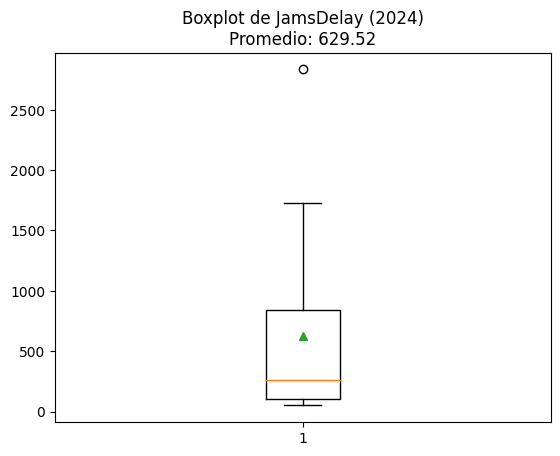

In [17]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
import matplotlib.pyplot as plt
import seaborn as sb
plt.boxplot(merged['jams_delay'], showmeans=True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


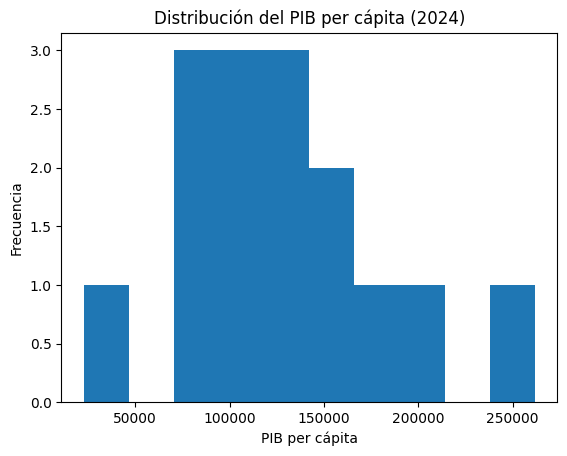

In [18]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
plt.hist(merged['city_gdp_capita'])
plt.title('Distribución del PIB per cápita (2024)')
plt.xlabel('PIB per cápita')
plt.ylabel('Frecuencia')
plt.show()


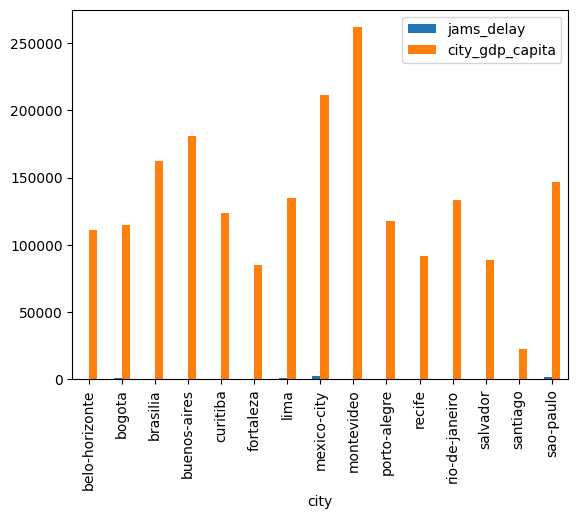

In [19]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot( kind= 'bar', x='city', y=['jams_delay', 'city_gdp_capita'])
plt.xticks(rotation=90)
plt.show()

In [20]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Resumen Ejecutivo

El objetivo de este análisis fue evaluar la relación entre la movilidad urbana —medida a través de indicadores como congestión vehicular y tiempos de retraso— y la productividad económica, representada principalmente por el PIB per cápita en ciudades latinoamericanas. Las variables clave incluyeron métricas de tráfico (como jams_delay e índice de congestión) y variables económicas (PIB per cápita, desempleo y población), las cuales son relevantes para identificar oportunidades estratégicas de inversión en infraestructura de transporte.

El análisis consideró datos correspondientes al año 2024, abarcando un total de 30 ciudades de América Latina. La información provino de fuentes como TomTom Traffic Index y OECD Cities, integrando indicadores de movilidad urbana y desempeño económico a nivel ciudad, lo que permitió una visión comparativa regional.

A nivel metodológico, se realizó un proceso de limpieza de datos que incluyó la estandarización de formatos numéricos y de fecha, así como la homogenización de nombres de columnas. Posteriormente, los datos fueron agregados por ciudad-año y combinados mediante una unión de tipo INNER, asegurando que solo se analizaran registros completos en ambos datasets. Para validar la calidad de los datos y explorar patrones iniciales, se emplearon visualizaciones como distribuciones, detección de valores atípicos y análisis de tendencias generales.

Los hallazgos indican que no existe una correlación lineal clara entre altos niveles de congestión y el PIB per cápita. Es decir, ciudades con economías similares presentan niveles de tráfico significativamente distintos, lo que sugiere que otros factores —como planificación urbana o infraestructura— influyen de manera importante. Sin embargo, se identificaron casos relevantes: Bogotá destaca por combinar alta congestión (1,141 minutos de retraso) con un PIB per cápita moderado, mientras que Buenos Aires presenta congestión considerable pese a un PIB más alto. Asimismo, se detectaron limitaciones en la comparabilidad debido a diferencias de escala entre variables.

En función de estos resultados, se recomienda priorizar a Bogotá como ciudad estratégica para inversión en infraestructura de transporte, ya que muestra una relación más evidente entre alta congestión y menor productividad relativa. Adicionalmente, se sugiere realizar análisis estadísticos más profundos (como correlaciones y regresiones), normalizar las escalas de las variables para mejorar la interpretación y validar la consistencia de las fuentes de datos. Estas acciones permitirán fortalecer la toma de decisiones y enfocar mejor las inversiones en movilidad urbana.